In [28]:
from matplotlib import pyplot as plt
from glob import glob
import numpy as np
from collections import defaultdict
import librosa.display

Loading the spectrograms from both classes

In [14]:
class0 = glob("../preprocessing_pipeline/spectogram_data/Class0/*")
class1 = glob("../preprocessing_pipeline/spectogram_data/Class1/*")

class0_specs = []
class1_specs = []
class0_per_speaker = defaultdict(int)
class1_per_speaker = defaultdict(int)

for person in class0:
    person_path = glob(f'{person}/*.npz')
    for path in person_path:
        specs = np.load(path, allow_pickle=True)
        class0_specs.extend(specs['X'])
        class0_per_speaker[person] += len(specs['X'])

for person in class1:
    person_path = glob(f'{person}/*.npz')
    for path in person_path:
        specs = np.load(path, allow_pickle=True)
        class1_specs.extend(specs['X'])
        class1_per_speaker[person] += len(specs['X'])

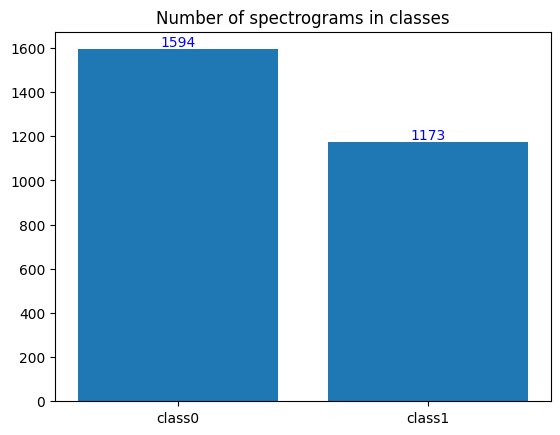

In [5]:
class0_count = len(class0_specs)
class1_count = len(class1_specs)

fig, ax = plt.subplots()
x_positions = [0, 1]
bars = ax.bar(['class0', 'class1'], [class0_count, class1_count])

ax.bar_label(bars, label_type='edge', color='blue')
ax.title.set_text('Number of spectrograms in classes')
plt.show()



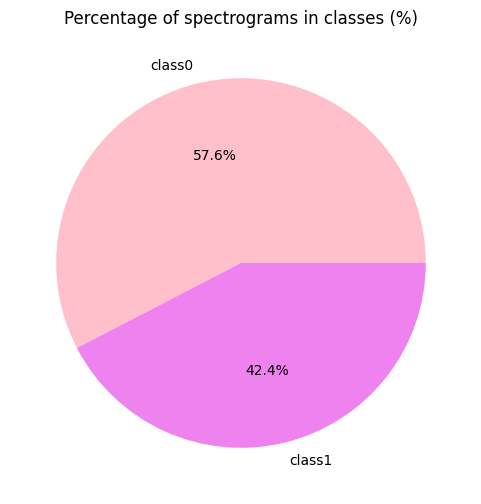

In [6]:
plt.figure(figsize=(6, 6))
class0_count = len(class0_specs)
class1_count = len(class1_specs)
plt.pie([class0_count, class1_count], labels=['class0', 'class1'], colors=['pink', 'violet'], autopct='%1.1f%%')

plt.title('Percentage of spectrograms in classes (%)')
plt.show()

C:\Users\piotrek\Desktop\PW\IML\voice_recognition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


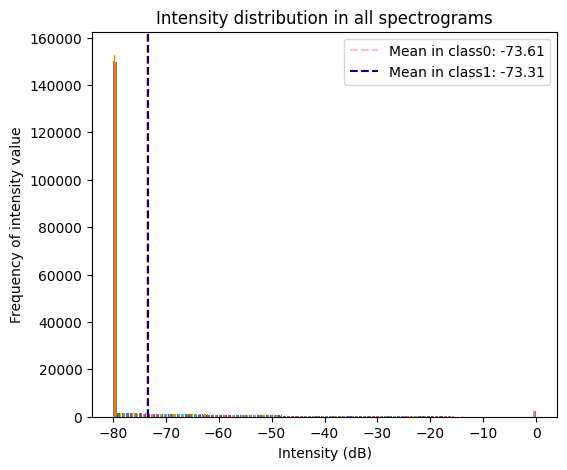

In [7]:
fig, axes = plt.subplots(1, figsize=(6, 5))
#todo add density??
class0_values = np.concatenate(class0_specs)
class1_values = np.concatenate(class1_specs)

axes.hist(class0_values, bins=100)
axes.axvline(np.mean(class0_values), color='pink', linestyle='--', label=f'Mean in class0: {np.mean(class0_values):.2f}')
axes.hist(class1_values, bins=100)
axes.axvline(np.mean(class1_values), color='navy', linestyle='--', label=f'Mean in class1: {np.mean(class1_values):.2f}')
axes.set_title('Intensity distribution in all spectrograms')
axes.set_xlabel('Intensity (dB)')
axes.set_ylabel('Frequency of intensity value')
axes.legend()

plt.show()

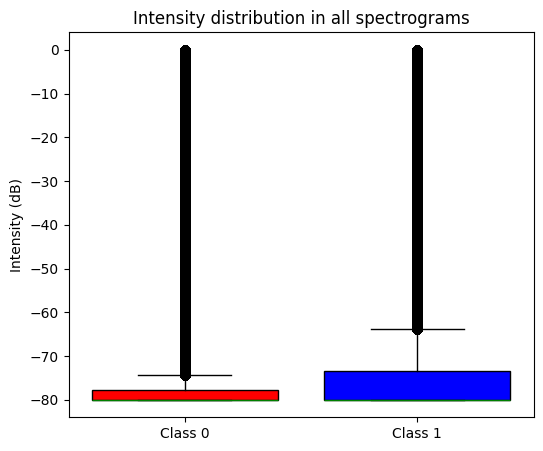

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
# all values from spectrograms from class 0 and class 1
bp = ax.boxplot([class0_values.flatten(), class1_values.flatten()],
                tick_labels=['Class 0', 'Class 1'],
                patch_artist=True,
                widths=0.8,
                medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Intensity distribution in all spectrograms')
ax.set_ylabel('Intensity (dB)')

plt.show()

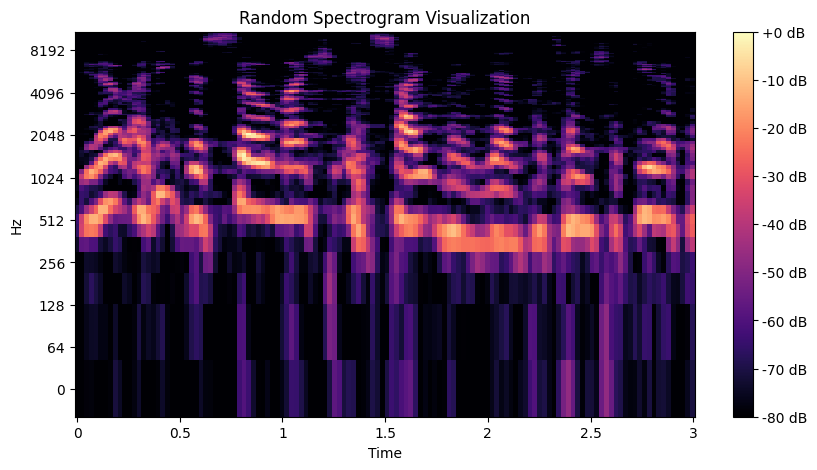

In [32]:
#todo random spect from speaker class 0
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(class0_specs[0], x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, ax=ax, format='%+2.f dB')
ax.set_title("Random Spectrogram Visualization")
plt.show()

In [ ]:
#todo random spect from noise

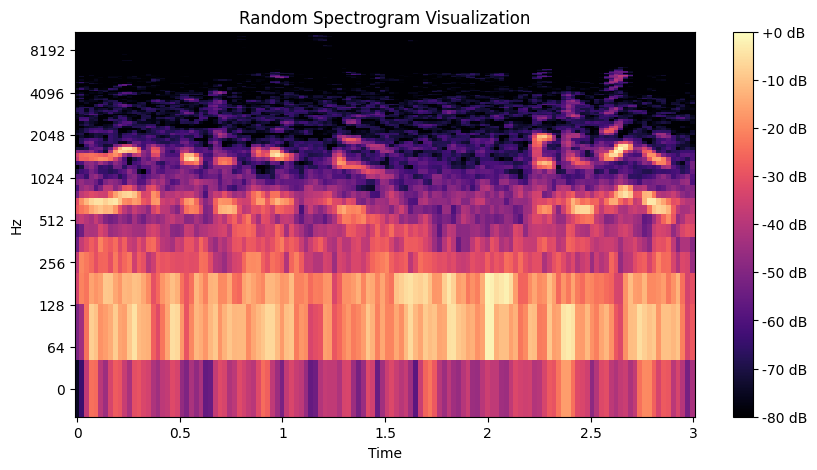

In [33]:
#todo random spect speaker class 1
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(class1_specs[0], x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, ax=ax, format='%+2.f dB')
ax.set_title("Random Spectrogram Visualization")
plt.show()

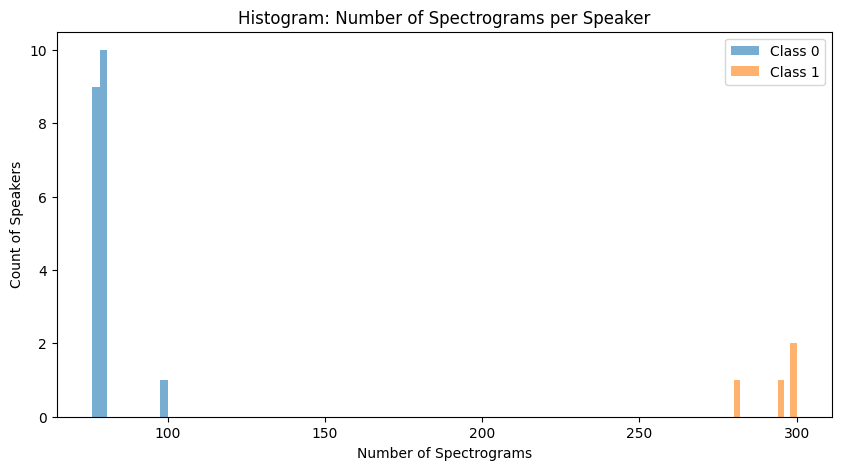

In [23]:
#TODO number of spectrograms per speaker in class1, speaker in class0 and per noise histogram
#to check if the quality of the recordings was so bad for a speaker that because of silence removal we didn't get that many spectograms
plt.figure(figsize=(10,5))

# class 0 histogram
plt.hist(class0_per_speaker.values(), alpha=0.6, label="Class 0", bins=10)

# class 1 histogram
plt.hist(class1_per_speaker.values(), alpha=0.6, label="Class 1", bins=10)

plt.title("Histogram: Number of Spectrograms per Speaker")
plt.xlabel("Number of Spectrograms")
plt.ylabel("Count of Speakers")
plt.legend()
plt.show()

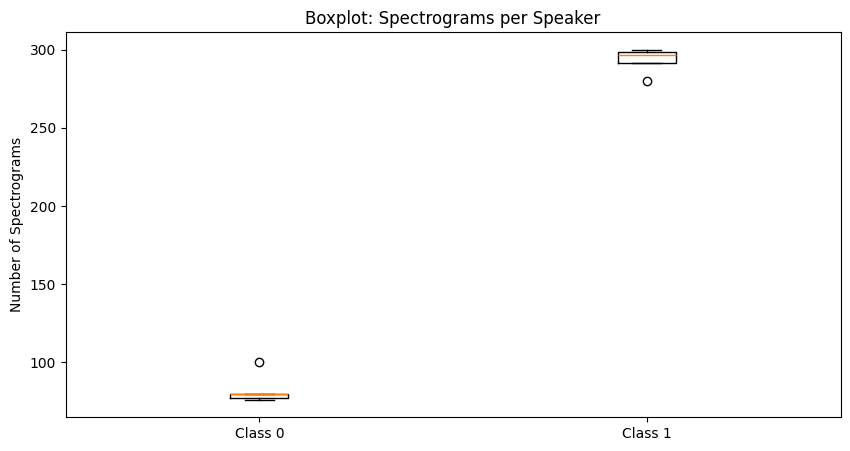

In [26]:
#TODO number of spectrograms per speaker in class1, speaker in class0 and per noise boxplot
plt.figure(figsize=(10,5))

plt.boxplot([list(class0_per_speaker.values()), list(class1_per_speaker.values())], tick_labels=["Class 0", "Class 1"])

plt.title("Boxplot: Spectrograms per Speaker")
plt.ylabel("Number of Spectrograms")
plt.show()